# Descriptive and Exploratory Data Analysis
 This will serve as the baseline for a later validation of the model

## Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
manifest = pd.read_csv("../Ch_1_Data_Preparation/manifest.csv")

In [3]:
pd.Timedelta("1D")

Timedelta('1 days 00:00:00')

In [3]:
manifest

,Unnamed: 0,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,...,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,building_id,run_id,seed,sum_n_persons
0,0,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,...,True,False,21.0,24.0,1,False,0,run_000000,1000000,30
1,1,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,...,True,False,21.0,24.0,1,False,0,run_000001,1000001,30
2,2,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,...,True,False,21.0,24.0,1,False,0,run_000002,1000002,30
3,3,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,...,True,False,21.0,24.0,1,False,1,run_000003,1000003,36
4,4,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,...,True,False,21.0,24.0,1,False,1,run_000004,1000004,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,14395,DE,TH,Semi,DE.12,160.8,1,hot,False,12,...,True,False,21.0,24.0,1,False,4798,run_014395,1014395,4
14396,14396,DE,TH,Semi,DE.12,160.8,1,hot,False,12,...,True,False,21.0,24.0,1,False,4798,run_014396,1014396,4
14397,14397,DE,TH,Semi,DE.12,58.1,1,hot,False,14,...,True,False,21.0,24.0,1,False,4799,run_014397,1014397,1
14398,14398,DE,TH,Semi,DE.12,58.1,1,hot,False,14,...,True,False,21.0,24.0,1,False,4799,run_014398,1014398,1


In [4]:
bldgs = manifest.drop_duplicates(subset=["building_id"],keep="first", ignore_index=True)

In [6]:
bldgs = bldgs[["buildingType", "buildingAgeBin","a_ref", "sum_n_persons", "n_apartments", "year_type", "future", "climateRegion"]]
bldgs["area_per_person"] =bldgs[""]

In [7]:
bldgs

,buildingType,buildingAgeBin,a_ref,sum_n_persons,n_apartments,year_type,future,climateRegion
0,AB,DE.02,1234.5,30,14,cold,False,4
1,AB,DE.02,1722.3,36,20,hot,True,12
2,AB,DE.02,1976.7,30,19,hot,False,7
3,AB,DE.02,1132.7,27,13,average,False,2
4,AB,DE.02,1495.7,36,18,hot,False,13
...,...,...,...,...,...,...,...,...
4795,TH,DE.12,50.6,1,1,hot,False,10
4796,TH,DE.12,134.6,2,1,average,True,1
4797,TH,DE.12,144.7,4,1,cold,False,12
4798,TH,DE.12,160.8,4,1,hot,False,12


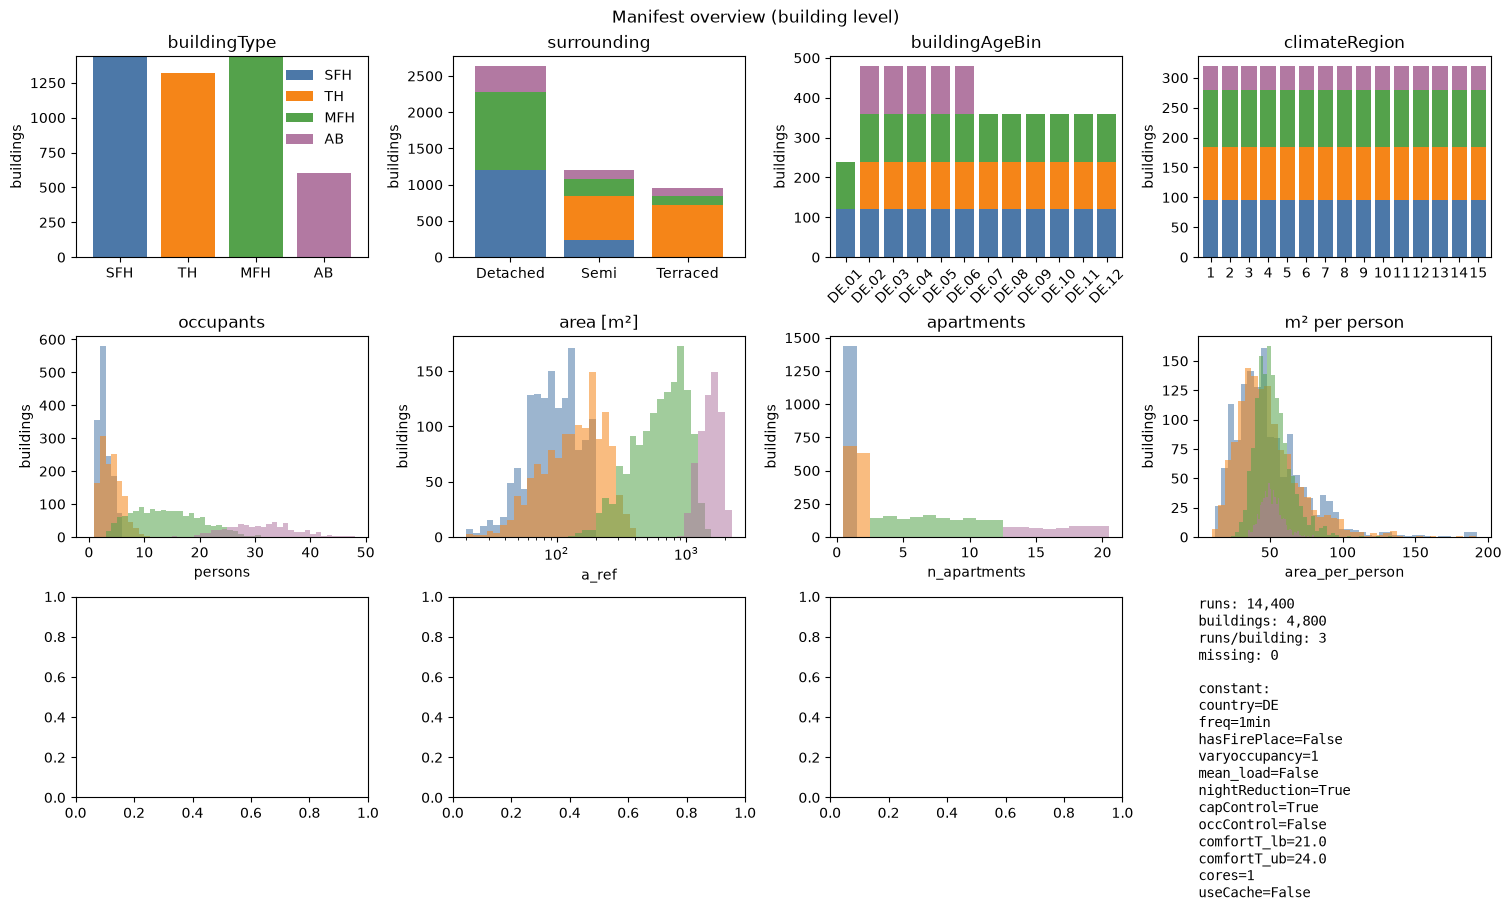

In [11]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TYPES  = ["SFH", "TH", "MFH", "AB"]
COLORS = dict(zip(TYPES, ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]))


# ---------- data prep ----------
def load_manifest(path) -> pd.DataFrame:
    m = pd.read_parquet(path)
    if isinstance(m["n_persons"].iloc[0], str):
        m["n_persons"] = m["n_persons"].apply(ast.literal_eval)
    m["persons"]         = m["n_persons"].apply(sum)
    m["area_per_person"] = m["a_ref"] / m["persons"]
    m["persons_per_apt"] = m["persons"] / m["n_apartments"]
    return m


# ---------- reusable panel helpers ----------
def stacked_bar(ax, b, col, order=None, rotate=0):
    """Building counts per `col`, stacked by buildingType."""
    ct = pd.crosstab(b[col], b["buildingType"]).reindex(columns=TYPES, fill_value=0)
    if order is not None:
        ct = ct.reindex(order)
    ct.plot.bar(stacked=True, ax=ax, color=[COLORS[t] for t in TYPES], legend=False, width=0.8)
    ax.set(xlabel="", ylabel="buildings", title=col)
    ax.tick_params(axis="x", rotation=rotate)


def hist_by_type(ax, b, col, bins, title, log=False):
    """Overlaid step histograms per buildingType."""
    for t in TYPES:
        ax.hist(b.loc[b.buildingType == t, col], bins=bins,
                histtype="stepfilled", alpha=0.55, color=COLORS[t], label=t)
    ax.set(title=title, xlabel=col, ylabel="buildings")
    if log:
        ax.set_xscale("log")


def summary_text(ax, m, b):
    """Text panel: run/building counts, missing values, constant params."""
    const = [c for c in m.columns if c != "n_persons" and m[c].nunique() == 1]
    txt = (f"runs: {len(m):,}\nbuildings: {len(b):,}\n"
           f"runs/building: {len(m)//len(b)}\nmissing: {int(m.isna().sum().sum())}\n\n"
           "constant:\n" + "\n".join(f"{c}={m[c].iloc[0]}" for c in const))
    ax.axis("off")
    ax.text(0, 1, txt, va="top", family="monospace")


# ---------- main figure ----------
def overview(m: pd.DataFrame, save=None):
    b = m.drop_duplicates("building_id")          # building level (3 runs share static params)

    fig, ax = plt.subplots(3, 4, figsize=(15, 9), constrained_layout=True)

    # Row 1: categorical composition, stacked by type
    stacked_bar(ax[0, 0], b, "buildingType",   order=TYPES)
    stacked_bar(ax[0, 1], b, "surrounding")
    stacked_bar(ax[0, 2], b, "buildingAgeBin", order=sorted(b.buildingAgeBin.unique()), rotate=45)
    stacked_bar(ax[0, 3], b, "climateRegion",  order=sorted(b.climateRegion.unique()))
    ax[0, 0].legend(TYPES, frameon=False)

    # Row 2: numeric distributions, overlaid by type
    hist_by_type(ax[1, 0], b, "persons",         bins=np.arange(0, b.persons.max() + 2), title="occupants")
    hist_by_type(ax[1, 1], b, "a_ref",           bins=np.geomspace(b.a_ref.min(), b.a_ref.max(), 40),
                 title="area [m²]", log=True)
    hist_by_type(ax[1, 2], b, "n_apartments",    bins=np.arange(0.5, b.n_apartments.max() + 1.5), title="apartments")
    hist_by_type(ax[1, 3], b, "area_per_person", bins=40, title="m² per person")

    # Row 3: relations + summary
    # [2,0] scatter: a_ref vs persons, colour by type, log-log
    # [2,1] boxplot: persons_per_apt by type
    # [2,2] heatmap: pd.crosstab(b.buildingAgeBin, b.climateRegion) + colorbar
    summary_text(ax[2, 3], m, b)

    fig.suptitle("Manifest overview (building level)")
    if save:
        fig.savefig(save, dpi=150)
    return fig


if __name__ == "__main__":
    overview(load_manifest("../Ch_1_Data_Preparation/manifest.parquet"))
    plt.show()